In [ ]:
# Import required libraries
import pandas as pd   # for data handling
import ast            # to convert string → list


In [2]:
# Load resume dataset (already contains extracted skills)
resume_df = pd.read_csv("../dataset/resume_with_skills.csv")

# Load job dataset (contains job roles and extracted job skills)
job_df = pd.read_csv("../dataset/job_with_skills.csv")

# Display first few rows to verify
resume_df.head()

,resume_file,resume_text,cleaned_text,detected_skills
0,10030015.pdf,ENGINEERING LAB TECHNICIAN\nCareer Focus\nMy m...,engineering lab technician career focus main o...,"['c', 'go', 'r']"
1,10070224.pdf,PUBLIC RELATIONS DIRECTOR\nSummary\nTalented P...,public relation director summary talented pr p...,"['c', 'r', 'excel', 'communication', 'go']"
2,10176815.pdf,AVIATION ELECTRONICS TECHNICIAN\nSummary\nSeek...,aviation electronics technician summary seekin...,"['c', 'r', 'excel', 'communication', 'html', '..."
3,10235429.pdf,FITNESS INSTRUCTOR\nProfessional Summary\nDyna...,fitness instructor professional summary dynami...,"['c', 'r', 'excel', 'communication', 'leadersh..."
4,10281555.pdf,CONSTRUCTION SITE MANAGER\nSummary\n\nsupervis...,construction site manager summary supervising ...,"['c', 'teamwork', 'problem solving', 'r', 'exc..."


In [3]:
# Select a job role for comparison
job_role = "Data Scientist"

# Extract skills required for this job role
job_skills = job_df[job_df["job_role"] == job_role]["job_skills"].values[0]

# Convert string representation → actual list
job_skills = ast.literal_eval(job_skills)

# Print job skills to verify
print("Job Skills:", job_skills)

Job Skills: ['python', 'machine learning', 'deep learning', 'sql', 'pandas', 'numpy', 'data visualization']


In [4]:
def skill_gap(resume_skills, job_skills):
    """
    This function compares resume skills with job skills
    and returns:
    1. Matched skills (common)
    2. Missing skills (gap)
    """

    # Convert string → list (since CSV stores list as string)
    resume_skills = ast.literal_eval(resume_skills)

    # Convert to set for easy comparison
    resume_set = set(resume_skills)
    job_set = set(job_skills)

    # Find matched skills (intersection)
    matched = list(resume_set.intersection(job_set))

    # Find missing skills (difference)
    missing = list(job_set - resume_set)

    return matched, missing

In [ ]:
# Apply skill gap function to each resume
resume_df[["matched_skills", "missing_skills"]] = resume_df["skills"].apply(
    lambda x: pd.Series(skill_gap(x, job_skills))
)

# Display updated dataset
resume_df.head()

KeyError: 'skills'

In [6]:
print(resume_df.columns)

Index(['resume_file', 'resume_text', 'cleaned_text', 'detected_skills'], dtype='object')


In [7]:
resume_df[["matched_skills", "missing_skills"]] = resume_df["detected_skills"].apply(
    lambda x: pd.Series(skill_gap(x, job_skills))
)

In [8]:
def skill_gap(resume_skills, job_skills):
    import ast
    
    # Convert string → list if needed
    if isinstance(resume_skills, str):
        resume_skills = ast.literal_eval(resume_skills)

    resume_set = set(resume_skills)
    job_set = set(job_skills)

    matched = list(resume_set.intersection(job_set))
    missing = list(job_set - resume_set)

    return matched, missing

In [9]:
# Load BERT similarity scores
bert_df = pd.read_csv("../results/bert_scores.csv")

# Check columns
print(bert_df.columns)
bert_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../results/bert_scores.csv'

In [10]:
import os
print(os.listdir("../results"))

[]


In [11]:
import pandas as pd

bert_df = pd.read_csv("../results/bert_scores.csv")

# Check columns
print(bert_df.columns)
bert_df.head()

Index(['resume_file', 'resume_text', 'cleaned_text', 'bert_match_score'], dtype='object')


,resume_file,resume_text,cleaned_text,bert_match_score
0,10030015.pdf,ENGINEERING LAB TECHNICIAN\nCareer Focus\nMy m...,engineering lab technician career focus main o...,0.255010
1,10070224.pdf,PUBLIC RELATIONS DIRECTOR\nSummary\nTalented P...,public relation director summary talented pr p...,0.041889
2,10176815.pdf,AVIATION ELECTRONICS TECHNICIAN\nSummary\nSeek...,aviation electronics technician summary seekin...,0.180715
3,10235429.pdf,FITNESS INSTRUCTOR\nProfessional Summary\nDyna...,fitness instructor professional summary dynami...,0.075147
4,10281555.pdf,CONSTRUCTION SITE MANAGER\nSummary\n\nsupervis...,construction site manager summary supervising ...,0.154441


In [13]:
final_df = resume_df.merge(bert_df, on="resume_file")
final_df = final_df.sort_values(by="bert_match_score", ascending=False)

In [14]:
final_df.head()

,resume_file,resume_text_x,cleaned_text_x,detected_skills,matched_skills,missing_skills,resume_text_y,cleaned_text_y,bert_match_score
14,11580408.pdf,INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,"['c', 'problem solving', 'r', 'excel', 'commun...",[sql],"[python, machine learning, pandas, data visual...",INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,0.306287
93,19161572.pdf,CONSULTANT\nProfile\nKnowledge of most common ...,consultant profile knowledge common operating ...,"['c', 'r', 'excel']",[],"[python, machine learning, pandas, data visual...",CONSULTANT\nProfile\nKnowledge of most common ...,consultant profile knowledge common operating ...,0.296935
107,21156767.pdf,Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,"['c', 'python', 'r', 'java', 'machine learning...","[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,0.293634
242,41152404.pdf,TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,"['c', 'risk management', 'automation testing',...",[sql],"[python, machine learning, pandas, data visual...",TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,0.288426
16,11813872.pdf,"VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,"['c', 'python', 'r', 'java', 'leadership', 'ti...","[sql, python]","[machine learning, pandas, data visualization,...","VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,0.287792


In [15]:
final_df.to_csv("../results/final_output.csv", index=False)

print("Final output saved successfully!")

Final output saved successfully!


In [16]:
# Calculate match percentage
def match_percentage(matched_skills, job_skills):
    return (len(matched_skills) / len(job_skills)) * 100

# Apply
final_df["match_percentage"] = final_df["matched_skills"].apply(
    lambda x: match_percentage(x, job_skills)
)

final_df.head()

,resume_file,resume_text_x,cleaned_text_x,detected_skills,matched_skills,missing_skills,resume_text_y,cleaned_text_y,bert_match_score,match_percentage
14,11580408.pdf,INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,"['c', 'problem solving', 'r', 'excel', 'commun...",[sql],"[python, machine learning, pandas, data visual...",INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,0.306287,14.285714
93,19161572.pdf,CONSULTANT\nProfile\nKnowledge of most common ...,consultant profile knowledge common operating ...,"['c', 'r', 'excel']",[],"[python, machine learning, pandas, data visual...",CONSULTANT\nProfile\nKnowledge of most common ...,consultant profile knowledge common operating ...,0.296935,0.000000
107,21156767.pdf,Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,"['c', 'python', 'r', 'java', 'machine learning...","[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,0.293634,57.142857
242,41152404.pdf,TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,"['c', 'risk management', 'automation testing',...",[sql],"[python, machine learning, pandas, data visual...",TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,0.288426,14.285714
16,11813872.pdf,"VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,"['c', 'python', 'r', 'java', 'leadership', 'ti...","[sql, python]","[machine learning, pandas, data visualization,...","VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,0.287792,28.571429


In [17]:
# Keyword-based matching (baseline comparison)
import ast

def keyword_match(resume_skills, job_skills):
    if isinstance(resume_skills, str):
        resume_skills = ast.literal_eval(resume_skills)

    return len(set(resume_skills).intersection(set(job_skills)))

# Apply
final_df["keyword_score"] = final_df["detected_skills"].apply(
    lambda x: keyword_match(x, job_skills)
)

final_df.head()

,resume_file,resume_text_x,cleaned_text_x,detected_skills,matched_skills,missing_skills,resume_text_y,cleaned_text_y,bert_match_score,match_percentage,keyword_score
14,11580408.pdf,INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,"['c', 'problem solving', 'r', 'excel', 'commun...",[sql],"[python, machine learning, pandas, data visual...",INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,0.306287,14.285714,1
93,19161572.pdf,CONSULTANT\nProfile\nKnowledge of most common ...,consultant profile knowledge common operating ...,"['c', 'r', 'excel']",[],"[python, machine learning, pandas, data visual...",CONSULTANT\nProfile\nKnowledge of most common ...,consultant profile knowledge common operating ...,0.296935,0.000000,0
107,21156767.pdf,Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,"['c', 'python', 'r', 'java', 'machine learning...","[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,0.293634,57.142857,4
242,41152404.pdf,TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,"['c', 'risk management', 'automation testing',...",[sql],"[python, machine learning, pandas, data visual...",TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,0.288426,14.285714,1
16,11813872.pdf,"VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,"['c', 'python', 'r', 'java', 'leadership', 'ti...","[sql, python]","[machine learning, pandas, data visualization,...","VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,0.287792,28.571429,2


In [18]:
# Show top 5 candidates
final_df[["resume_file", "bert_match_score", "match_percentage"]].head()

,resume_file,bert_match_score,match_percentage
14,11580408.pdf,0.306287,14.285714
93,19161572.pdf,0.296935,0.000000
107,21156767.pdf,0.293634,57.142857
242,41152404.pdf,0.288426,14.285714
16,11813872.pdf,0.287792,28.571429


In [19]:
import ast

# Define CS-related skills
cs_skills = [
    "python", "java", "machine learning", "deep learning",
    "sql", "html", "css", "javascript", "react", "node.js",
    "data analysis", "pandas", "numpy", "tensorflow"
]

# Function to filter resumes
def is_cs_resume(skills):
    if isinstance(skills, str):
        skills = ast.literal_eval(skills)
    
    return any(skill in cs_skills for skill in skills)

# Apply filter
filtered_resume_df = resume_df[resume_df["detected_skills"].apply(is_cs_resume)]

print("Total resumes:", len(resume_df))
print("Filtered resumes:", len(filtered_resume_df))

Total resumes: 300
Filtered resumes: 58


In [20]:
resume_df = filtered_resume_df

In [21]:
print(len(resume_df))

58


In [22]:
resume_df[["matched_skills", "missing_skills"]] = resume_df["detected_skills"].apply(
    lambda x: pd.Series(skill_gap(x, job_skills))
)

In [23]:
bert_df = pd.read_csv("../results/bert_scores.csv")

final_df = resume_df.merge(bert_df, on="resume_file")

final_df = final_df.sort_values(by="bert_match_score", ascending=False)

In [24]:
final_df["match_percentage"] = final_df["matched_skills"].apply(
    lambda x: (len(x) / len(job_skills)) * 100
)

In [25]:
final_df.to_csv("../results/final_output_refined.csv", index=False)

print("Refined output saved!")

Refined output saved!


In [26]:
# Select important columns for display
display_df = final_df[[
    "resume_file",
    "bert_match_score",
    "match_percentage",
    "matched_skills",
    "missing_skills"
]]

# Show top 10 candidates
display_df.head(10)

,resume_file,bert_match_score,match_percentage,matched_skills,missing_skills
2,11580408.pdf,0.306287,14.285714,[sql],"[python, machine learning, pandas, data visual..."
20,21156767.pdf,0.293634,57.142857,"[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]"
49,41152404.pdf,0.288426,14.285714,[sql],"[python, machine learning, pandas, data visual..."
3,11813872.pdf,0.287792,28.571429,"[sql, python]","[machine learning, pandas, data visualization,..."
13,16186411.pdf,0.275059,14.285714,[sql],"[python, machine learning, pandas, data visual..."
5,12351749.pdf,0.274297,14.285714,[machine learning],"[python, pandas, data visualization, deep lear..."
38,32985311.pdf,0.251913,28.571429,"[sql, python]","[machine learning, pandas, data visualization,..."
46,38896303.pdf,0.250238,0.000000,[],"[python, machine learning, pandas, data visual..."
10,14871762.pdf,0.249427,28.571429,"[sql, python]","[machine learning, pandas, data visualization,..."
23,23464505.pdf,0.248851,14.285714,[sql],"[python, machine learning, pandas, data visual..."


In [27]:
# Add ranking
display_df = display_df.reset_index(drop=True)
display_df["rank"] = display_df.index + 1

# Move rank column to front
display_df = display_df[[
    "rank",
    "resume_file",
    "bert_match_score",
    "match_percentage",
    "matched_skills",
    "missing_skills"
]]

display_df.head(10)

,rank,resume_file,bert_match_score,match_percentage,matched_skills,missing_skills
0,1,11580408.pdf,0.306287,14.285714,[sql],"[python, machine learning, pandas, data visual..."
1,2,21156767.pdf,0.293634,57.142857,"[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]"
2,3,41152404.pdf,0.288426,14.285714,[sql],"[python, machine learning, pandas, data visual..."
3,4,11813872.pdf,0.287792,28.571429,"[sql, python]","[machine learning, pandas, data visualization,..."
4,5,16186411.pdf,0.275059,14.285714,[sql],"[python, machine learning, pandas, data visual..."
5,6,12351749.pdf,0.274297,14.285714,[machine learning],"[python, pandas, data visualization, deep lear..."
6,7,32985311.pdf,0.251913,28.571429,"[sql, python]","[machine learning, pandas, data visualization,..."
7,8,38896303.pdf,0.250238,0.000000,[],"[python, machine learning, pandas, data visual..."
8,9,14871762.pdf,0.249427,28.571429,"[sql, python]","[machine learning, pandas, data visualization,..."
9,10,23464505.pdf,0.248851,14.285714,[sql],"[python, machine learning, pandas, data visual..."


In [28]:
# Show top candidate details
display_df.iloc[0]

rank                                                                1
resume_file                                              11580408.pdf
bert_match_score                                             0.306287
match_percentage                                            14.285714
matched_skills                                                  [sql]
missing_skills      [python, machine learning, pandas, data visual...
Name: 0, dtype: object

In [29]:
display_df.to_csv("../results/final_display_output.csv", index=False)

print("Final display output saved!")

Final display output saved!


In [30]:
print("Total resumes analyzed:", len(display_df))
print("Top match percentage:", display_df["match_percentage"].max())
print("Average match percentage:", display_df["match_percentage"].mean())

Total resumes analyzed: 58
Top match percentage: 57.14285714285714
Average match percentage: 10.098522167487682


In [31]:
# Create explanation for each resume
def generate_explanation(row):
    return f"""
    The candidate matches {len(row['matched_skills'])} required skills.
    However, they are missing {len(row['missing_skills'])} important skills: {row['missing_skills']}.
    """

# Apply
final_df["explanation"] = final_df.apply(generate_explanation, axis=1)

final_df.head()

,resume_file,resume_text_x,cleaned_text_x,detected_skills,matched_skills,missing_skills,resume_text_y,cleaned_text_y,bert_match_score,match_percentage,explanation
2,11580408.pdf,INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,"['c', 'problem solving', 'r', 'excel', 'commun...",[sql],"[python, machine learning, pandas, data visual...",INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,0.306287,14.285714,\n The candidate matches 1 required skills....
20,21156767.pdf,Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,"['c', 'python', 'r', 'java', 'machine learning...","[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,0.293634,57.142857,\n The candidate matches 4 required skills....
49,41152404.pdf,TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,"['c', 'risk management', 'automation testing',...",[sql],"[python, machine learning, pandas, data visual...",TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,0.288426,14.285714,\n The candidate matches 1 required skills....
3,11813872.pdf,"VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,"['c', 'python', 'r', 'java', 'leadership', 'ti...","[sql, python]","[machine learning, pandas, data visualization,...","VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,0.287792,28.571429,\n The candidate matches 2 required skills....
13,16186411.pdf,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)\n...,database programmeranalyst net developer summa...,"['c', 'bootstrap', 'scrum', 'r', 'java', 'exce...",[sql],"[python, machine learning, pandas, data visual...",DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)\n...,database programmeranalyst net developer summa...,0.275059,14.285714,\n The candidate matches 1 required skills....


In [32]:
print(final_df["explanation"].iloc[0])


    The candidate matches 1 required skills.
    However, they are missing 6 important skills: ['python', 'machine learning', 'pandas', 'data visualization', 'deep learning', 'numpy'].
    


In [33]:
display_df["explanation"] = final_df["explanation"]

display_df.head(5)

,rank,resume_file,bert_match_score,match_percentage,matched_skills,missing_skills,explanation
0,1,11580408.pdf,0.306287,14.285714,[sql],"[python, machine learning, pandas, data visual...",\n The candidate matches 0 required skills....
1,2,21156767.pdf,0.293634,57.142857,"[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",\n The candidate matches 0 required skills....
2,3,41152404.pdf,0.288426,14.285714,[sql],"[python, machine learning, pandas, data visual...",\n The candidate matches 1 required skills....
3,4,11813872.pdf,0.287792,28.571429,"[sql, python]","[machine learning, pandas, data visualization,...",\n The candidate matches 2 required skills....
4,5,16186411.pdf,0.275059,14.285714,[sql],"[python, machine learning, pandas, data visual...",\n The candidate matches 1 required skills....


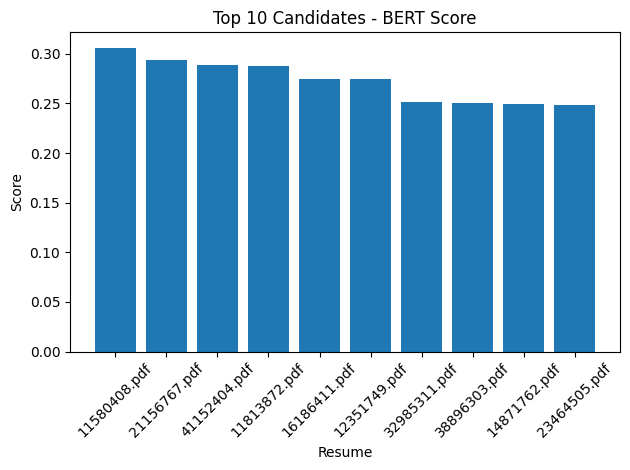

In [35]:
import matplotlib.pyplot as plt

# Plot top 10 match scores
top10 = final_df.head(10)

plt.figure()
plt.bar(top10["resume_file"], top10["bert_match_score"])
plt.xticks(rotation=45)
plt.title("Top 10 Candidates - BERT Score")
plt.xlabel("Resume")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [36]:
final_df["missing_count"] = final_df["missing_skills"].apply(len)
final_df["matched_count"] = final_df["matched_skills"].apply(len)

final_df.head()

,resume_file,resume_text_x,cleaned_text_x,detected_skills,matched_skills,missing_skills,resume_text_y,cleaned_text_y,bert_match_score,match_percentage,explanation,missing_count,matched_count
2,11580408.pdf,INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,"['c', 'problem solving', 'r', 'excel', 'commun...",[sql],"[python, machine learning, pandas, data visual...",INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,0.306287,14.285714,\n The candidate matches 1 required skills....,6,1
20,21156767.pdf,Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,"['c', 'python', 'r', 'java', 'machine learning...","[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,0.293634,57.142857,\n The candidate matches 4 required skills....,3,4
49,41152404.pdf,TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,"['c', 'risk management', 'automation testing',...",[sql],"[python, machine learning, pandas, data visual...",TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,0.288426,14.285714,\n The candidate matches 1 required skills....,6,1
3,11813872.pdf,"VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,"['c', 'python', 'r', 'java', 'leadership', 'ti...","[sql, python]","[machine learning, pandas, data visualization,...","VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,0.287792,28.571429,\n The candidate matches 2 required skills....,5,2
13,16186411.pdf,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)\n...,database programmeranalyst net developer summa...,"['c', 'bootstrap', 'scrum', 'r', 'java', 'exce...",[sql],"[python, machine learning, pandas, data visual...",DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)\n...,database programmeranalyst net developer summa...,0.275059,14.285714,\n The candidate matches 1 required skills....,6,1


In [37]:
print("Average Match %:", final_df["match_percentage"].mean())
print("Max Match %:", final_df["match_percentage"].max())
print("Min Match %:", final_df["match_percentage"].min())

Average Match %: 10.098522167487682
Max Match %: 57.14285714285714
Min Match %: 0.0


In [38]:
def recommendation(row):
    if row["match_percentage"] > 70:
        return "Highly Suitable"
    elif row["match_percentage"] > 40:
        return "Moderately Suitable"
    else:
        return "Needs Improvement"

final_df["recommendation"] = final_df.apply(recommendation, axis=1)

final_df.head()

,resume_file,resume_text_x,cleaned_text_x,detected_skills,matched_skills,missing_skills,resume_text_y,cleaned_text_y,bert_match_score,match_percentage,explanation,missing_count,matched_count,recommendation
2,11580408.pdf,INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,"['c', 'problem solving', 'r', 'excel', 'commun...",[sql],"[python, machine learning, pandas, data visual...",INFORMATION TECHNOLOGY COORDINATOR\nCareer Ove...,information technology coordinator career over...,0.306287,14.285714,\n The candidate matches 1 required skills....,6,1,Needs Improvement
20,21156767.pdf,Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,"['c', 'python', 'r', 'java', 'machine learning...","[sql, data visualization, python, machine lear...","[pandas, deep learning, numpy]",Pavithra Shetty\nSummary\n\nCustomer-oriented ...,pavithra shetty summary customeroriented princ...,0.293634,57.142857,\n The candidate matches 4 required skills....,3,4,Moderately Suitable
49,41152404.pdf,TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,"['c', 'risk management', 'automation testing',...",[sql],"[python, machine learning, pandas, data visual...",TEST ANALYST-INTERN/CONTRACTOR\nProfile\n3+ ye...,test analystinterncontractor profile year prof...,0.288426,14.285714,\n The candidate matches 1 required skills....,6,1,Needs Improvement
3,11813872.pdf,"VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,"['c', 'python', 'r', 'java', 'leadership', 'ti...","[sql, python]","[machine learning, pandas, data visualization,...","VP, PRINCIPAL\nSummary\n\nI am highly skilled,...",vp principal summary highly skilledgrowth mind...,0.287792,28.571429,\n The candidate matches 2 required skills....,5,2,Needs Improvement
13,16186411.pdf,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)\n...,database programmeranalyst net developer summa...,"['c', 'bootstrap', 'scrum', 'r', 'java', 'exce...",[sql],"[python, machine learning, pandas, data visual...",DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)\n...,database programmeranalyst net developer summa...,0.275059,14.285714,\n The candidate matches 1 required skills....,6,1,Needs Improvement


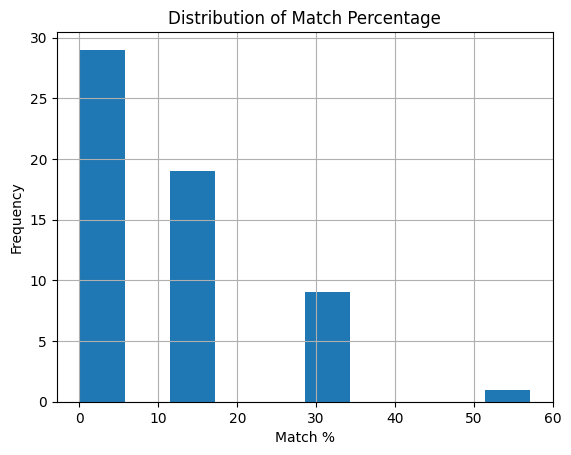

In [39]:
# Show distribution
final_df["match_percentage"].hist()
plt.title("Distribution of Match Percentage")
plt.xlabel("Match %")
plt.ylabel("Frequency")
plt.show()